# Multilevel Graph with focus on NLP for now.

In [1]:
from typing import Any

import nltk
import glob
import random


In [2]:
pos_imdb = glob.glob("../data/datasets/IMDB/test/raw/positive/*.txt")
neg_imdb = glob.glob("../data/datasets/IMDB/test/raw/negative/*.txt")

imdb_test = pos_imdb + neg_imdb

random.shuffle(imdb_test)

selected_file = imdb_test[0]
print(f"Selected file: {selected_file}")
doc = open(selected_file).read()

print("-" * 50)
print(doc)
print("-" * 50)

Selected file: ../data/datasets/IMDB/test/raw/negative/49360.txt
--------------------------------------------------
I'll bet none of you knew that the famous Conquistador Hernando Cortes made a preliminary scouting expedition to Mexico before taking on the Aztecs. Good thing he did because he would never have known about those T Rexs that inhabited one particular valley where the locals revered them as gods.<br /><br />That was understandable. What wasn't was the casting of blue eyed Ian Ziering as Cortes. Even with the blond hair made famous in Beverly Hills 90210 dyed black, Ian looked positively ridiculous. At least he made no attempt at a Spanish accent.<br /><br />The real hero of Tyrannosaurus Azteca is Marco Sanchez also late of a television series with a semi-recurring role in Walker Texas Ranger as Detective Sandoval of the Dallas PD. He finds true love with an Aztec princess and life would be just perfect if it wasn't for those pesky prehistoric beasts the natives worship.<br

In [3]:
doc = doc.replace("<br />", "\n")
print(doc)

I'll bet none of you knew that the famous Conquistador Hernando Cortes made a preliminary scouting expedition to Mexico before taking on the Aztecs. Good thing he did because he would never have known about those T Rexs that inhabited one particular valley where the locals revered them as gods.

That was understandable. What wasn't was the casting of blue eyed Ian Ziering as Cortes. Even with the blond hair made famous in Beverly Hills 90210 dyed black, Ian looked positively ridiculous. At least he made no attempt at a Spanish accent.

The real hero of Tyrannosaurus Azteca is Marco Sanchez also late of a television series with a semi-recurring role in Walker Texas Ranger as Detective Sandoval of the Dallas PD. He finds true love with an Aztec princess and life would be just perfect if it wasn't for those pesky prehistoric beasts the natives worship.

Tyrannosaurus Azteca looks like they used some outtakes from the famous Sid&Marty Krofft series the Land of the Lost. All that was needed

In [4]:
sentences = nltk.sent_tokenize(doc)
[print(sentence.strip(), "\n--") for sentence in sentences]

I'll bet none of you knew that the famous Conquistador Hernando Cortes made a preliminary scouting expedition to Mexico before taking on the Aztecs. 
--
Good thing he did because he would never have known about those T Rexs that inhabited one particular valley where the locals revered them as gods. 
--
That was understandable. 
--
What wasn't was the casting of blue eyed Ian Ziering as Cortes. 
--
Even with the blond hair made famous in Beverly Hills 90210 dyed black, Ian looked positively ridiculous. 
--
At least he made no attempt at a Spanish accent. 
--
The real hero of Tyrannosaurus Azteca is Marco Sanchez also late of a television series with a semi-recurring role in Walker Texas Ranger as Detective Sandoval of the Dallas PD. 
--
He finds true love with an Aztec princess and life would be just perfect if it wasn't for those pesky prehistoric beasts the natives worship. 
--
Tyrannosaurus Azteca looks like they used some outtakes from the famous Sid&Marty Krofft series the Land of 

[None, None, None, None, None, None, None, None, None, None, None, None]

In [5]:
tokens_0 = nltk.word_tokenize(sentences[0].lower().strip())
print(tokens_0)

['i', "'ll", 'bet', 'none', 'of', 'you', 'knew', 'that', 'the', 'famous', 'conquistador', 'hernando', 'cortes', 'made', 'a', 'preliminary', 'scouting', 'expedition', 'to', 'mexico', 'before', 'taking', 'on', 'the', 'aztecs', '.']


## Char N-Grams

In [6]:
import os
from collections import Counter


def get_char_ngrams(text, n):
    return [text[i:i + n] for i in range(len(text) - n + 1)]


def clean_text(text):
    return text.lower().replace("<br />", "\n").replace("\ufeff", "")


def process_corpus(directory, n):
    ngram_counter = Counter()

    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            with open(os.path.join(directory, filename), "r", encoding="utf-8") as f:
                text = clean_text(f.read())  # normalize to lowercase
                ngrams = get_char_ngrams(text, n)
                ngram_counter.update(ngrams)

    return ngram_counter


# Usage
# directory_path = "../data/datasets/Imprisonment-IT/train/raw/NotReleased"
directory_path = "../data/datasets/IMDB/train/raw/positive"
n = 1  # for trigrams
top_ngrams = process_corpus(directory_path, n).most_common(20000)

# Display results
for ngram, count in top_ngrams:
    print(f"{ngram!r}: {count}")


' ': 4552936
'e': 2478186
't': 1913462
'a': 1683913
'i': 1598562
'o': 1518972
's': 1412966
'n': 1376644
'r': 1180558
'h': 1118604
'l': 922041
'd': 720991
'c': 585751
'm': 574724
'u': 541481
'f': 472129
'g': 426790
'y': 426668
'w': 400559
'p': 349637
'b': 321003
'v': 259758
'.': 252535
',': 226061
'k': 172302
"'": 100391
'\n': 77620
'-': 51511
'"': 50482
'j': 47645
'x': 35403
')': 29255
'(': 28797
'z': 19247
'!': 18690
'q': 16832
'0': 14985
'1': 14948
'9': 8744
'?': 7707
':': 7493
'2': 5862
';': 5767
'/': 5459
'*': 4420
'5': 4158
'8': 3934
'7': 3792
'3': 3771
'4': 3163
'6': 2678
'&': 2618
'é': 1141
'\x96': 1094
'\x85': 598
'`': 589
'_': 572
'$': 413
'=': 347
'%': 294
'+': 278
'\x97': 274
'#': 254
'´': 193
'á': 135
'}': 120
'{': 117
']': 115
'ö': 112
'[': 108
'>': 94
'è': 93
'\x91': 83
'’': 79
'~': 75
'@': 72
'ó': 62
'\t': 60
'ä': 56
'¨': 54
'ü': 50
'^': 49
'í': 48
'ñ': 43
'à': 41
'£': 40
'–': 37
'¡': 37
'ô': 36
'ï': 31
'ç': 30
'<': 30
'ã': 28
'\xa0': 26
'“': 25
'»': 25
'”': 24
'«': 23
'

# Preprocessing

In [1]:
import glob
import random
import tqdm
import nltk
import unicodedata
import re
import contractions
import nltk
import spacy
import glob

# Ensure necessary NLTK data is downloaded
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Load SpaCy English model
nlp = spacy.load('en_core_web_lg')
nlp = spacy.load


In [8]:

pos_imdb = glob.glob("../data/datasets/IMDB/train/raw/positive/*.txt")
neg_imdb = glob.glob("../data/datasets/IMDB/train/raw/negative/*.txt")

imdb_test = pos_imdb + neg_imdb

random.shuffle(imdb_test)

In [9]:
positive_raw_dataset = [open(f).read() for f in pos_imdb]
negative_raw_dataset = [open(f).read() for f in neg_imdb]


In [10]:
import unicodedata
import re
import contractions
import nltk
import spacy
from nltk.tokenize import sent_tokenize

# Ensure necessary NLTK data is downloaded
nltk.download('punkt', quiet=True)

# Load spaCy English model
nlp = spacy.load('en_core_web_lg')


def preprocessing_imdb(text: str):
    def _replace_chars_and_symbols(target):
        # Mapping less frequent symbols to words or removing them
        replace_chars_with_words = {
            # "&": " and ",
            # "%": " percent ",
            "--": " - ",
            "²": " squared ",
            "®": " registered ",
            "•": " bullet ",
            "<": " less than ",
            ">": " greater than ",
            "¬": " not ",
            "�": "",
            "™": " trademark ",
            "°": " degrees ",
            "½": " half ",
            "¼": " quarter ",
            "¾": " three quarters ",
            "–": "-", "—": "-",
            "‘": "'", "’": "'", "“": '"', "”": '"', "´": "'", "`": "'", "¨": '"',
            "…": "...", "×": " x ", "÷": " divided by ", "±": " plus-minus ",
            "§": " section ", "¶": " paragraph ", "€": " euro ", "£": " pound ",
            "¥": " yen ", "$": " dollar ", "¢": " cent ", "#": " number ", "@": " at ",
            "^": "", "~": "", "|": "", "\\": "",
            "\"": "",
            "\t": " ", "\n": "\n", "\r": " ",
        }

        # Replace specific HTML tags and BOM
        target = target.replace("<br />", "\n").replace("\ufeff", "")

        # Remove or replace specific HTML/XML-like tags
        html_tags = ['<em>', '</em>', '<p>', '</p>', '<spoiler>', '</spoiler>']
        for tag in html_tags:
            target = target.replace(tag, '')

        # Replace '<3' with 'love'
        target = target.replace('<3', ' love ')

        # Remove sequences like '<<<<<', '>>>>>>>>>', '<sp?'
        target = re.sub(r'<{2,}', '', target)
        target = re.sub(r'>{2,}', '', target)
        target = re.sub(r'<sp\?', '', target)

        # Apply replacements
        for char, replacement in replace_chars_with_words.items():
            target = target.replace(char, replacement)

        return target

    def _normalize_unicode(text):
        # Normalize unicode characters to ASCII
        text = unicodedata.normalize('NFKD', text)
        text = text.encode('ascii', 'ignore').decode('utf-8', 'ignore')
        return text

    def _expand_contractions(text):
        # Expand contractions using the contractions library
        return contractions.fix(text)

    def _extract_possessive_relations(doc):
        relations = []
        for token in doc:
            if token.dep_ == 'poss':
                possessor = token.text
                possessed = token.head.text
                relations.append((possessor, 'possesses', possessed))
        return relations

    # Step 1: Replace less frequent characters and symbols
    pre_processed = _replace_chars_and_symbols(text)

    # Step 2: Normalize unicode characters
    pre_processed = _normalize_unicode(pre_processed)

    # Step 3: Expand contractions
    pre_processed = _expand_contractions(pre_processed)

    # Step 4: Tokenize into sentences
    splitted_sentences = sent_tokenize(pre_processed)

    # Step 5: Process each sentence with spaCy and extract possessive relations
    processed_sentences = []

    for sentence in splitted_sentences:

        doc = nlp(sentence)
        # Extract possessive relations
        # possessive_relations = _extract_possessive_relations(doc)
        # Selective lowercasing: preserve 'I' and proper nouns
        words = []
        special_case = False
        for i, token in enumerate(doc):
            if token.text == "'s" and i > 0:
                # Handle possessive 's
                words[-1] = words[-1] + "'s"
            elif token.text == "'":

                head = token.head
                if head.dep_ == "poss":
                    # e.g., Glovers'
                    if len(words) > 0:
                        words[-1] = words[-1] + "'"
                elif re.match(r"\d{2}s", head.text):
                    # e.g., '70s ➝ '70s
                    words.append("'" + head.text)
                elif head.text.startswith("'") or (i + 1 < len(doc) and doc[i + 1].text.endswith("s")):
                    continue
                    # stylized or partial decade, skip extra quote
                else:
                    continue  # skip standalone apostrophes
                    # Most likely just a quote
                    # print(f"Else case: Token={token.text}, Head={head.text}, Dep={token.dep_}, Pos={token.pos_}" )

            elif token.text == "I" or token.pos_ == "PROPN":
                words.append(token.text)
            else:
                words.append(token.text.lower())

        if special_case:
            print("Sentence:", sentence)
            print("words:", words)
        processed_sentence = ' '.join(words)

        recover_chars = {
            " , ": ", ",
            " .": ". ",
            " ; ": "; ",
            " ; ": "; ",
            " ; ": "; ",
            " \" ": " ",
            " ! ": "! ",
            "( ": " (",
            " )": ") ",
            " - ": "-",
            " !": "! ",
            " ?": "? ",
            " :": ": ",
            "  ": " "
        }

        for i in range(3):
            for char in recover_chars.keys():
                processed_sentence = processed_sentence.replace(char, recover_chars[char])

        processed_sentence = re.sub(r'(\w)([\(\{\[])', r'\1 \2', processed_sentence)
        processed_sentence = re.sub(r'([\)\}\]])(\w)', r'\1 \2', processed_sentence)

        processed_sentences.append(processed_sentence.strip())

    return processed_sentences, splitted_sentences


In [11]:
import random
import nltk
from collections import Counter
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

nltk.download('punkt', quiet=True)


def tokenize(text):
    return nltk.word_tokenize(text.lower())


def vocab_size(texts):
    all_tokens = []
    for text in texts:
        all_tokens.extend(tokenize(text))
    return len(set(all_tokens))


def token_overlap(original_texts, processed_texts):
    overlaps = []
    for orig, proc in zip(original_texts, processed_texts):
        orig_tokens = set(tokenize(orig))
        proc_tokens = set(tokenize(proc))
        if len(orig_tokens) == 0:
            overlaps.append(0.0)
            continue
        overlap = len(orig_tokens.intersection(proc_tokens)) / len(orig_tokens)
        overlaps.append(overlap)
    return sum(overlaps) / len(overlaps) if len(overlaps) > 0 else 0.0


def calculate_perplexity(texts, model, tokenizer, device='cpu'):
    model.eval()
    total_loss = 0.0
    total_length = 0
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors='pt').to(device)
            outputs = model(**inputs, labels=inputs['input_ids'])
            loss = outputs.loss
            length = inputs['input_ids'].size(1)
            total_loss += loss.item() * length
            total_length += length
    perplexity = torch.exp(torch.tensor(total_loss / total_length)).item()
    return perplexity


def sample_inspection(original_texts, processed_texts, n=5):
    indices = random.sample(range(len(original_texts)), n)
    for idx in indices:
        print(f"--- Example {idx} ---")
        print("Original:  ", original_texts[idx])
        print("Processed: ", processed_texts[idx])
        print()



In [12]:
# Your preprocessing loop with metrics integration
preprocessed_dataset = []
processed_sentences_flat = []
original_sentences_flat = []

positive_processed_dataset = []
negative_processed_dataset = []

random.shuffle(positive_raw_dataset)
random.shuffle(negative_raw_dataset)

for doc_text in tqdm.tqdm(positive_raw_dataset[:200], desc="Preprocessing Positive IMDB"):
    preprocessed_doc, original_doc = preprocessing_imdb(doc_text)  # This returns list of sentences
    processed_sentences_flat.extend(preprocessed_doc)
    original_sentences_flat.extend(original_doc)

    positive_processed_dataset.append(preprocessed_doc)

for doc_text in tqdm.tqdm(negative_raw_dataset[:200], desc="Preprocessing Negative IMDB"):
    preprocessed_doc, original_doc = preprocessing_imdb(doc_text)  # This returns list of sentences
    processed_sentences_flat.extend(preprocessed_doc)
    original_sentences_flat.extend(original_doc)

    negative_processed_dataset.append(preprocessed_doc)


Preprocessing Negative IMDB: 100%|██████████| 200/200 [00:14<00:00, 13.51it/s]


In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
# model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

In [14]:
print(f"Vocabulary size (original): {vocab_size(original_sentences_flat)}")
print(f"Vocabulary size (processed): {vocab_size(processed_sentences_flat)}")

avg_overlap = token_overlap(original_sentences_flat, processed_sentences_flat)
print(f"Average token overlap (processed vs original): {avg_overlap:.5f}")

# print("Loading GPT2 model for perplexity estimation... (may take a while)")
#
# ppl = calculate_perplexity(processed_sentences_flat, model, tokenizer, device=device)
# print(f"Perplexity on processed text (GPT-2): {ppl:.2f}")

print("\nRandom sample inspection:")
sample_inspection(original_sentences_flat, processed_sentences_flat, n=5)


Vocabulary size (original): 11615
Vocabulary size (processed): 11617
Average token overlap (processed vs original): 0.99213

Random sample inspection:
--- Example 526 ---
Original:   But when she is allowed to hire a trainee that can work for her, all this is about to change.
Processed:  but when she is allowed to hire a trainee that can work for her, all this is about to change.

--- Example 2154 ---
Original:   The man is acclaimed to be father by all of the children but one, who still prefers her brother.
Processed:  the man is acclaimed to be father by all of the children but one, who still prefers her brother.

--- Example 614 ---
Original:   The acting was superb, although I would have to mention Bill Nye in particular as giving an absolutely faultless performance.
Processed:  the acting was superb, although I would have to mention Bill Nye in particular as giving an absolutely faultless performance.

--- Example 1974 ---
Original:   Be thankful that Cam Archer exists in this wor

# Text to Graph

In [15]:
nlp = spacy.load('en_core_web_lg')

In [16]:
def process_doc_from_sentences(sentences):
    # sentences: list of str
    all_tokens = []
    sentence_token_indices = []  # to track which tokens belong to which sentence

    for sent in sentences:
        doc = nlp(sent)
        tokens = [token for token in doc if not token.is_space]
        start_idx = len(all_tokens)
        all_tokens.extend(tokens)
        sentence_token_indices.append((start_idx, len(all_tokens)))

    return all_tokens, sentence_token_indices


In [17]:
import torch
from torch_geometric.data import HeteroData
from sklearn.metrics.pairwise import cosine_similarity

list_sims = []


def build_hetero_graph_from_tokens(sentences):
    all_tokens, sentence_token_indices = process_doc_from_sentences(sentences)

    hetero_data = HeteroData()

    # Save tokens as strings
    all_tokens_text = [token.text for token in all_tokens]
    hetero_data['word'].tokens = all_tokens_text

    # Word nodes + embeddings
    word_embeddings = torch.tensor([token.vector for token in all_tokens], dtype=torch.float)
    hetero_data['word'].x = word_embeddings

    # Sentence nodes: average word embeddings per sentence
    sentence_embeddings = []
    for start, end in sentence_token_indices:
        if end > start:
            sent_emb = torch.mean(word_embeddings[start:end], dim=0)
        else:
            sent_emb = torch.zeros(word_embeddings.size(1))  # fallback for empty sentence
        sentence_embeddings.append(sent_emb)
    sentence_embeddings = torch.stack(sentence_embeddings)
    hetero_data['sentence'].x = sentence_embeddings

    # Document node: average sentence embeddings
    doc_embedding = torch.mean(sentence_embeddings, dim=0, keepdim=True)
    hetero_data['document'].x = doc_embedding

    # ==== Edges ====

    # Word sequence edges (within each sentence)
    word_seq_edges = []
    for start, end in sentence_token_indices:
        for i in range(start, end - 1):
            word_seq_edges.append([i, i + 1])
    if word_seq_edges:
        word_seq_edges = torch.tensor(word_seq_edges).t().contiguous()
    else:
        word_seq_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['word', 'seq', 'word'].edge_index = word_seq_edges

    # Dependency edges (token.head must be in all_tokens)
    token_to_idx = {token.i: idx for idx, token in enumerate(all_tokens)}
    word_dep_edges = []
    for idx, token in enumerate(all_tokens):
        head = token.head
        if head.i in token_to_idx and head.i != token.i:
            head_idx = token_to_idx[head.i]
            word_dep_edges.append([head_idx, idx])
    if word_dep_edges:
        word_dep_edges = torch.tensor(word_dep_edges).t().contiguous()
    else:
        word_dep_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['word', 'dep', 'word'].edge_index = word_dep_edges

    # Sentence sequence edges
    sent_seq_edges = [[i, i + 1] for i in range(len(sentences) - 1)]
    if sent_seq_edges:
        sent_seq_edges = torch.tensor(sent_seq_edges).t().contiguous()
    else:
        sent_seq_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['sentence', 'seq', 'sentence'].edge_index = sent_seq_edges

    # Sentence semantic similarity edges
    sims = cosine_similarity(sentence_embeddings)
    sent_sim_edges = []
    for i in range(len(sentences)):
        for j in range(i + 1, len(sentences)):
            list_sims.append(sims[i, j])
            if sims[i, j] > 0.9:
                sent_sim_edges.append([i, j])
                sent_sim_edges.append([j, i])
    if sent_sim_edges:
        sent_sim_edges = torch.tensor(sent_sim_edges).t().contiguous()
    else:
        sent_sim_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['sentence', 'sim', 'sentence'].edge_index = sent_sim_edges

    # Words -> Sentences (belongs)
    word_to_sent_edges = []
    for sent_idx, (start, end) in enumerate(sentence_token_indices):
        for word_idx in range(start, end):
            word_to_sent_edges.append([word_idx, sent_idx])
    if word_to_sent_edges:
        word_to_sent_edges = torch.tensor(word_to_sent_edges).t().contiguous()
    else:
        word_to_sent_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['word', 'belongs', 'sentence'].edge_index = word_to_sent_edges

    # Sentences -> Document (belongs)
    sent_to_doc_edges = torch.tensor([[i for i in range(len(sentences))], [0] * len(sentences)], dtype=torch.long)
    hetero_data['sentence', 'belongs', 'document'].edge_index = sent_to_doc_edges

    return hetero_data


In [18]:
import matplotlib.pyplot as plt
import networkx as nx
import torch_geometric.utils as pyg_utils


def plot_hetero_graph(hetero_data, filename=None):
    plt.clf()
    plt.figure(figsize=(30, 16))

    # Add node_type and node_idx attrs for conversion
    for ntype in hetero_data.node_types:
        hetero_data[ntype].node_type = [ntype] * hetero_data[ntype].num_nodes
        hetero_data[ntype].node_idx = list(range(hetero_data[ntype].num_nodes))

    G = pyg_utils.to_networkx(hetero_data, node_attrs=['node_type', 'node_idx'], to_multi=True)

    print("Edge types in hetero_data:", hetero_data.edge_types)
    for etype in hetero_data.edge_types:
        count = hetero_data[etype].edge_index.size(1)
        print(f"Edge type {etype}: {count} edges")

    node_type_colors = {
        'word': 'skyblue',
        'sentence': 'lightgreen',
        'document': 'orange'
    }

    edge_type_colors = {
        ('word', 'seq', 'word'): 'blue',
        ('word', 'dep', 'word'): 'gold',
        ('sentence', 'seq', 'sentence'): 'green',
        ('sentence', 'sim', 'sentence'): 'darkorange',
        ('word', 'belongs', 'sentence'): 'darkmagenta',
        ('sentence', 'belongs', 'document'): 'firebrick',
    }

    # Map (ntype, local_idx) -> global node id in NetworkX graph
    node_global_id = {}
    for node, attr in G.nodes(data=True):
        ntype = attr['node_type']
        local_idx = attr['node_idx']
        node_global_id[(ntype, local_idx)] = node

    # Build edge_to_type using global node ids
    edge_to_type = {}
    for etype in hetero_data.edge_types:
        edge_index = hetero_data[etype].edge_index
        src_type, rel_type, dst_type = etype
        for i in range(edge_index.size(1)):
            src_local = int(edge_index[0, i])
            dst_local = int(edge_index[1, i])
            src_global = node_global_id[(src_type, src_local)]
            dst_global = node_global_id[(dst_type, dst_local)]
            edge_to_type[(src_global, dst_global)] = etype

    pos = nx.spring_layout(G, seed=42)

    node_colors = []
    node_labels = {}

    tokens = getattr(hetero_data['word'], 'tokens', None)

    for node, attr in G.nodes(data=True):
        ntype = attr.get('node_type', 'unknown')
        nidx = attr.get('node_idx', node)
        color = node_type_colors.get(ntype, 'gray')
        node_colors.append(color)

        if ntype == 'word' and tokens is not None:
            label = f"{tokens[nidx]}"
        else:
            label = f"{ntype}\n{nidx}"
        node_labels[node] = label

    edge_colors = []
    edge_labels = {}

    for u, v, k, attr in G.edges(keys=True, data=True):
        etype = edge_to_type.get((u, v), None)
        color = edge_type_colors.get(etype, 'black')
        edge_colors.append(color)
        label = etype[1] if etype else '?'
        edge_labels[(u, v, k)] = label

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, alpha=0.9)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, connectionstyle='arc3, rad=0.1', arrowsize=15)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)

    # Uncomment to draw edge labels
    # ax = plt.gca()
    # for (u, v, k), label in edge_labels.items():
    #     x_mid = (pos[u][0] + pos[v][0]) / 2
    #     y_mid = (pos[u][1] + pos[v][1]) / 2
    #     ax.text(x_mid, y_mid, label, fontsize=7, color='gray', ha='center', va='center', backgroundcolor='white')

    plt.axis('off')
    plt.title('Heterogeneous Graph Visualization')

    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=300)
        print(f"Saved graph visualization to {filename}")
    else:
        plt.show()


In [19]:
# Usage example:
random.seed(2)
random.shuffle(preprocessed_dataset)
for i, doc_sentences in enumerate(preprocessed_dataset[:3]):  # just first 3 docs for demo
    hetero_graph = build_hetero_graph_from_tokens(doc_sentences)
    plot_hetero_graph(hetero_graph, f"File_{i:03d}.png")  # Saves as PNG

    # You can append or batch these graphs as needed


# Starting Again.

In [20]:
import numpy as np

full_dataset = positive_processed_dataset + negative_processed_dataset
print(f"Documents: {len(full_dataset)}")
num_sentences = [len(doc_sentences) for doc_sentences in full_dataset]

avg = np.median(num_sentences)
std = np.std(num_sentences)
print(f"Avg Sents: {avg:.2f}")
print(f"Std Sents: {std:.2f}")

Documents: 400
Avg Sents: 10.00
Std Sents: 8.78


(array([124., 158.,  59.,  31.,  12.,   7.,   3.,   3.,   2.,   1.]),
 array([ 1. ,  7.2, 13.4, 19.6, 25.8, 32. , 38.2, 44.4, 50.6, 56.8, 63. ]),
 <BarContainer object of 10 artists>)

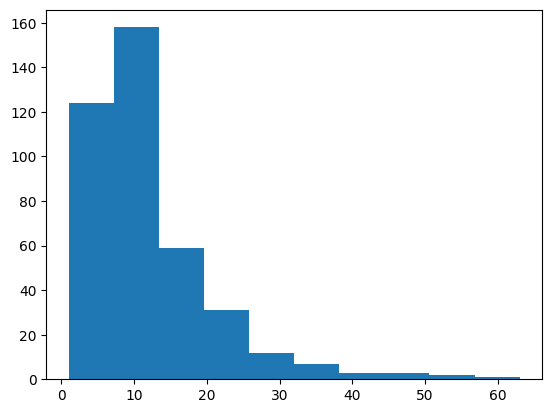

In [21]:
plt.hist(num_sentences)

In [22]:
preprocessed_dataset_documents = [" ".join(doc_sentences) for doc_sentences in preprocessed_dataset]

positive_processed_dataset_documents = [" ".join(doc_sentences) for doc_sentences in positive_processed_dataset]
negative_processed_dataset_documents = [" ".join(doc_sentences) for doc_sentences in negative_processed_dataset]


In [23]:
d1 = positive_processed_dataset_documents[0]
doc1 = nlp(d1)
doc1

this HTV series is beautiful. I strongly recommend watching the movie. it has got everything it should: remarkable script, strong characters, beautiful scenery and exceptional atmosphere. add some ambient score from Clannad and you receive unforgettable picture. I love every adventure movie from HTV I saw: return to Treasure Island, Smuggler, adventurer, but Robin of Sherwood beats them all. I would like to thank the whole HTV production team and Richard Carpenter in particular for giving me plenty of adventures and excitement. I have got the dvd release in my little movie collection. I regret very much movies like these are not made anymore.

# New Version

In [24]:
import spacy
import torch
import networkx as nx
import numpy as np
import logging
from torch_geometric.data import HeteroData
from transformers import AutoTokenizer, AutoModel
from torch.nn.functional import cosine_similarity, softmax, one_hot

# --- Setup Logging ---
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# --- Constants and Configuration ---
COMMON_DEP_LABELS = [
    "punct",
    "nsubj",
    "det",
    "prep",
    "advmod",
    "pobj",
    "conj",
    "aux",
    "amod",
    "dobj",
    "cc",
    "compound",
    "relcl",
    "ccomp",
    "poss",
    "acomp",
    "neg",
    "advcl",
    "attr",
    "mark",
    "dep"
]

all_dependency_counts = {

}


def get_positional_encoding(max_len: int, d_model: int) -> torch.Tensor:
    """Generates sinusoidal positional encodings."""
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    if d_model % 2 != 0:
        pe[:, 1::2] = torch.cos(position * div_term)[:, :pe[:, 1::2].shape[1]]
    else:
        pe[:, 1::2] = torch.cos(position * div_term)
    return pe


class DocumentGraphBuilder:
    """
    A class to build multi-level, heterogeneous graphs from textual documents.
    This version implements our final hybrid architecture design:
    - Static, pre-computed features for all intra-layer edges.
    - No pre-computed weights for hierarchical (belongs) edges.
    """

    def __init__(self,
                 spacy_model: str = 'en_core_web_lg',
                 embedding_model: str = 'sentence-transformers/all-MiniLM-L6-v2',
                 similarity_threshold: float = 0.9):
        logging.info("Initializing DocumentGraphBuilder...")
        self.nlp = spacy.load(spacy_model)
        self.tokenizer = AutoTokenizer.from_pretrained(embedding_model)
        self.model = AutoModel.from_pretrained(embedding_model)
        self.similarity_threshold = similarity_threshold
        self.dep_label_map = {label: i for i, label in enumerate(COMMON_DEP_LABELS)}
        self.used_deps = {i: 0 for i, label in enumerate(COMMON_DEP_LABELS)}
        self.embedding_dim = self.model.config.hidden_size
        logging.info(f"Models and configuration loaded successfully. Embedding dim: {self.embedding_dim}")

    def _get_batch_embedding(self, texts: list[str]) -> torch.Tensor:
        """Generates embeddings for a batch of texts."""
        inputs = self.tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
        with torch.no_grad():
            outputs = self.model(**inputs)
        return outputs.last_hidden_state.mean(dim=1)

    def process_documents(self, documents: list[str]) -> tuple[list[nx.MultiDiGraph], list[HeteroData]]:
        """Processes a list of documents and returns their graph representations."""
        nx_graphs = []
        hetero_graphs = []
        for i, doc_text in enumerate(documents):
            logging.info(f"--- Processing Document {i + 1}/{len(documents)} ---")
            nx_graph, hetero_graph = self.build_graphs_for_document(doc_text, doc_id=i)
            nx_graphs.append(nx_graph)
            hetero_graphs.append(hetero_graph)
        return nx_graphs, hetero_graphs

    def build_graphs_for_document(self, doc_text: str, doc_id: int) -> tuple[nx.MultiDiGraph, HeteroData]:
        """Constructs both graph representations for a single document."""
        spacy_doc = self.nlp(doc_text)
        sentences = list(spacy_doc.sents)
        nx_graph = nx.MultiDiGraph(doc_id=doc_id, text=doc_text)
        doc_node_id = f"doc_{doc_id}"

        content_words = [tok.text for tok in spacy_doc if not tok.is_stop and not tok.is_punct]
        unique_content_words = sorted(list(set(content_words)))
        word_embeddings_map = {}
        if unique_content_words:
            word_embeddings_map = {word: emb for word, emb in
                                   zip(unique_content_words, self._get_batch_embedding(unique_content_words))}

        max_sent_len = max((len(list(s)) for s in sentences), default=0)
        positional_encodings = get_positional_encoding(max_sent_len, self.embedding_dim)

        lemma_to_nodes = {}
        processed_sentences = []

        for sent_idx, sent in enumerate(sentences):
            word_nodes_in_sent = []
            contextual_embs_for_sent = []

            for token in sent:
                word_node_id = f"word_{doc_id}_{token.i}"
                contextual_emb = torch.zeros(self.embedding_dim)  # Default for stop/punct

                if token.is_stop or token.is_punct:
                    final_emb = torch.zeros(1, self.embedding_dim)
                else:
                    contextual_emb = word_embeddings_map.get(token.text, torch.zeros(self.embedding_dim))
                    pos_in_sent = token.i - sent.start
                    pos_emb = positional_encodings[pos_in_sent]
                    final_emb = (contextual_emb + pos_emb).unsqueeze(0)
                    contextual_embs_for_sent.append(contextual_emb)
                    if token.lemma_ not in lemma_to_nodes:
                        lemma_to_nodes[token.lemma_] = []
                    lemma_to_nodes[token.lemma_].append(word_node_id)

                # --- CHANGE: Store the initial contextual embedding for later use ('same_lemma' edges)
                nx_graph.add_node(word_node_id, type='word', text=token.text, x=final_emb,
                                  contextual_x=contextual_emb.unsqueeze(0))
                word_nodes_in_sent.append(word_node_id)

            if not contextual_embs_for_sent: continue

            # --- CHANGE: Simplified sentence embedding to an unweighted average. Attention is now learned by the GNN.
            final_sent_emb = torch.mean(torch.stack(contextual_embs_for_sent), dim=0).unsqueeze(0)
            sent_node_id = f"sent_{doc_id}_{sent_idx}"
            # This is the corrected line
            nx_graph.add_node(sent_node_id, type='sentence', text=sent.text, x=final_sent_emb, sentence_index=sent_idx)

            # --- CHANGE: Hierarchical 'belongs' edges now have no pre-computed weight.
            for wnid in word_nodes_in_sent:
                nx_graph.add_edge(wnid, sent_node_id, type='belongs')
            processed_sentences.append({'id': sent_node_id, 'embedding': final_sent_emb})

        if not processed_sentences:
            logging.warning(f"Document {doc_id} resulted in no processable sentences.")
            nx_graph.add_node(doc_node_id, type='document', text=f"DOC_{doc_id}",
                              x=torch.zeros((1, self.embedding_dim)))
            return nx_graph, self.to_hetero_data(nx_graph)

        # --- CHANGE: Simplified document embedding. Sophisticated aggregation is deferred to the GNN.
        final_sentence_embeddings = torch.cat([s['embedding'] for s in processed_sentences])
        final_doc_embedding = torch.mean(final_sentence_embeddings, dim=0, keepdim=True)
        nx_graph.add_node(doc_node_id, type='document', text=f"DOC_{doc_id}", x=final_doc_embedding)

        # --- CHANGE: Hierarchical 'belongs' edges have no pre-computed weight.
        for sent_data in processed_sentences:
            nx_graph.add_edge(sent_data['id'], doc_node_id, type='belongs')

        # --- CHANGE: Add static features to all intra-layer edges ---
        for lemma, nodes in lemma_to_nodes.items():
            if len(nodes) > 1:
                for i in range(len(nodes)):
                    for j in range(i + 1, len(nodes)):
                        u_context = nx_graph.nodes[nodes[i]]['contextual_x']
                        v_context = nx_graph.nodes[nodes[j]]['contextual_x']
                        sim = cosine_similarity(u_context, v_context).item()
                        feature = torch.tensor([sim])
                        nx_graph.add_edge(nodes[i], nodes[j], type='same_lemma', feature=feature)
                        nx_graph.add_edge(nodes[j], nodes[i], type='same_lemma', feature=feature)

        for token in spacy_doc:
            u_id = f"word_{doc_id}_{token.i}"
            if token.i + 1 < len(spacy_doc) and spacy_doc[token.i + 1].sent == token.sent:
                v_id = f"word_{doc_id}_{token.i + 1}"
                nx_graph.add_edge(u_id, v_id, type='seq', feature=torch.tensor([1.0]))
            if token.head != token and nx_graph.has_node(f"word_{doc_id}_{token.head.i}"):
                v_id = f"word_{doc_id}_{token.head.i}"
                dep_idx = self.dep_label_map.get(token.dep_, self.dep_label_map['dep'])
                dep_feature = one_hot(torch.tensor(dep_idx), num_classes=len(self.dep_label_map)).float()
                nx_graph.add_edge(u_id, v_id, type='dep', feature=dep_feature)
                dep_idx = self.dep_label_map.get(token.dep_, self.dep_label_map['dep'])
                self.used_deps[dep_idx] += 1

                if token.dep_ not in all_dependency_counts.keys():
                    all_dependency_counts[token.dep_] = 0
                all_dependency_counts[token.dep_] += 1

        sentence_node_ids = [s['id'] for s in processed_sentences]
        for i in range(len(sentence_node_ids)):
            if i + 1 < len(sentence_node_ids):
                nx_graph.add_edge(sentence_node_ids[i], sentence_node_ids[i + 1], type='seq',
                                  feature=torch.tensor([1.0]))
            for j in range(i + 1, len(sentence_node_ids)):
                sim = cosine_similarity(nx_graph.nodes[sentence_node_ids[i]]['x'],
                                        nx_graph.nodes[sentence_node_ids[j]]['x']).item()
                if sim > self.similarity_threshold:
                    nx_graph.add_edge(sentence_node_ids[i], sentence_node_ids[j], type='sim',
                                      feature=torch.tensor([sim]))

        logging.info(
            f"Constructed NetworkX graph: {nx_graph.number_of_nodes()} nodes, {nx_graph.number_of_edges()} edges.")
        hetero_data = self.to_hetero_data(nx_graph)
        logging.info(f"Converted to HeteroData graph: \n{hetero_data}")
        return nx_graph, hetero_data

    def to_hetero_data(self, nx_graph: nx.MultiDiGraph) -> HeteroData:
        # This function is generic and should handle the new 'feature' attributes correctly
        data = HeteroData()
        node_types = {d['type'] for _, d in nx_graph.nodes(data=True) if 'type' in d}
        node_mappings = {
            ntype: {n: i for i, (n, d) in enumerate(nx_graph.nodes(data=True)) if d.get('type') == ntype}
            for ntype in node_types
        }

        for ntype, mapping in node_mappings.items():
            nodes_of_type = list(mapping.keys())
            if not nodes_of_type: continue

            # Gather primary 'x' features
            if 'x' in nx_graph.nodes[nodes_of_type[0]]:
                data[ntype].x = torch.cat([nx_graph.nodes[n]['x'] for n in nodes_of_type], dim=0)

            # Gather other attributes like text, but avoid features we don't want on the final graph
            other_attrs = {k for k in nx_graph.nodes[nodes_of_type[0]].keys() if k not in ['type', 'x', 'contextual_x']}
            for attr in other_attrs:
                values = [nx_graph.nodes[n][attr] for n in nodes_of_type]
                data[ntype][attr] = values

        for u, v, attrs in nx_graph.edges(data=True):
            src_type, dst_type = nx_graph.nodes[u].get('type'), nx_graph.nodes[v].get('type')
            if not src_type or not dst_type: continue

            edge_type = attrs['type']
            edge_tuple = (src_type, edge_type, dst_type)
            if u not in node_mappings[src_type] or v not in node_mappings[dst_type]: continue

            src_idx, dst_idx = node_mappings[src_type][u], node_mappings[dst_type][v]

            if 'edge_index' not in data[edge_tuple]:
                data[edge_tuple].edge_index = torch.empty((2, 0), dtype=torch.long)

            edge_index = torch.tensor([[src_idx], [dst_idx]], dtype=torch.long)
            data[edge_tuple].edge_index = torch.cat([data[edge_tuple].edge_index, edge_index], dim=1)

            # This loop now correctly captures the 'feature' attribute for intra-layer edges
            for attr_key, attr_val in attrs.items():
                if attr_key == 'type': continue
                if attr_key not in data[edge_tuple]: data[edge_tuple][attr_key] = []
                data[edge_tuple][attr_key].append(attr_val)

        for store in data.edge_stores:
            for key, value in store.items():
                if key != 'edge_index' and isinstance(value, list) and value:
                    try:
                        if isinstance(value[0], torch.Tensor):
                            # Use stack for features that are vectors/tensors themselves
                            store[key] = torch.stack(value, dim=0).squeeze(1) if value[0].numel() > 1 else torch.tensor(
                                value)
                        else:
                            store[key] = torch.tensor(value)
                    except (TypeError, ValueError, RuntimeError) as e:
                        logging.warning(f"Could not convert edge attribute '{key}' to tensor: {e}")
                        pass
        return data

In [25]:
import spacy
import torch
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import logging
from torch_geometric.data import HeteroData
from transformers import AutoTokenizer, AutoModel
from torch.nn.functional import cosine_similarity, softmax, one_hot
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle  # For drawing the grouping boxes
from pyvis.network import Network  # Import the new library


# --- Utility and Analysis Functions ---

def visualize_explanatory_graph(nx_graph: nx.MultiDiGraph):
    """
    Draws a high-quality, explanatory graph.
    UPDATED: Visualizes static edge features instead of pre-computed attention.
    """
    fig, ax = plt.subplots(figsize=(70, 30))
    pos = {}

    # --- 1. Define Color and Style Maps (No Change) ---
    node_color_map = {'document': '#d62828', 'sentence': '#003049', 'word': '#f77f00'}
    edge_color_map = {
        'belongs': '#2a9d8f', 'seq': '#e76f51', 'dep': '#8d99ae',
        'same_lemma': '#6a4c93', 'sim': '#118ab2'
    }

    # --- 2-3. Positioning Logic (No Change) ---
    # (The existing logic for node positioning remains effective)
    nodes_by_type = {'document': [], 'sentence': [], 'word': []}
    sent_to_words = {}
    for node, data in nx_graph.nodes(data=True):
        nodes_by_type[data['type']].append(node)
        if data['type'] == 'sentence':
            sent_to_words[node] = []
    for u, v, data in nx_graph.edges(data=True):
        if data.get('type') == 'belongs' and nx_graph.nodes[u]['type'] == 'word':
            sent_to_words[v].append(u)
    y_coords = {'document': 1.0, 'sentence': 0.0, 'word': -1.0}
    pos[nodes_by_type['document'][0]] = (0.5, y_coords['document'])
    sorted_sents = sorted(nodes_by_type['sentence'], key=lambda n: nx_graph.nodes[n]['sentence_index'])
    num_sentences = len(sorted_sents)
    total_plot_width = 0.9
    left_margin = (1 - total_plot_width) / 2
    if num_sentences > 1:
        group_space_ratio = 0.9
        total_group_width = total_plot_width * group_space_ratio
        total_gap_width = total_plot_width * (1 - group_space_ratio)
        single_group_width = total_group_width / num_sentences
        single_gap_width = total_gap_width / (num_sentences - 1)
    else:
        single_group_width = total_plot_width
        single_gap_width = 0
    current_x = left_margin
    for sent_node in sorted_sents:
        x_start = current_x
        x_end = x_start + single_group_width
        sent_x = (x_start + x_end) / 2
        pos[sent_node] = (sent_x, y_coords['sentence'])
        words_in_sent = sorted(sent_to_words[sent_node], key=lambda n: nx_graph.nodes[n]['position_in_doc'])
        num_words = len(words_in_sent)
        padding = 0.1 * single_group_width
        word_x_coords = np.linspace(x_start + padding, x_end - padding, num_words) if num_words > 1 else [sent_x]
        y_base = y_coords['word']
        y_stagger_offset = 0.2
        for j, word_node in enumerate(words_in_sent):
            y_pos = y_base if j % 2 == 0 else y_base - y_stagger_offset
            pos[word_node] = (word_x_coords[j], y_pos)
        rect = Rectangle((x_start, y_coords['word'] - y_stagger_offset - 0.1),
                         width=single_group_width, height=0.4 + y_stagger_offset,
                         facecolor='#f8f9fa', edgecolor='#ced4da', linestyle='--', alpha=0.6, zorder=0)
        ax.add_patch(rect)
        current_x = x_end + single_gap_width

    # --- 4. Labels and Sizes (No Change) ---
    labels, node_colors, node_sizes = {}, [], []
    for node, data in nx_graph.nodes(data=True):
        node_colors.append(node_color_map[data['type']])
        text_label = data['text']
        if data['type'] == 'word':
            labels[node] = text_label
            node_sizes.append(1000 + len(text_label) * 250)
        elif data['type'] == 'sentence':
            labels[node] = f"SENT_{data['sentence_index']}"
            node_sizes.append(5000)
        else:
            labels[node] = text_label
            node_sizes.append(6000)

    # --- 5. Draw Graph Elements (UPDATED LOGIC) ---
    nx.draw_networkx_nodes(nx_graph, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0, ax=ax)
    nx.draw_networkx_labels(nx_graph, pos, labels=labels, font_size=9, font_weight='bold', font_color='white', ax=ax)

    for u, v, data in nx_graph.edges(data=True):
        edge_type = data['type']
        edge_color = edge_color_map.get(edge_type, '#b7b7a4')

        # --- CHANGE: Updated edge style logic ---
        # 'belongs' edges are now fixed style, as their weight is learned.
        if edge_type == 'belongs':
            alpha = 0.9
            lw = 2.5
        # For other edges, use the static feature to determine style.
        else:
            alpha = 0.7
            # Use the scalar feature for line width if it exists
            feature_val = data.get('feature', torch.tensor([1.0])).item()
            lw = 1.0 + (feature_val * 3.0)  # Scale feature (0-1) to a visible width

        rad = 0.15
        if hash(u) > hash(v): rad = -rad
        if nx_graph.nodes[u]['type'] == nx_graph.nodes[v]['type']: rad = 0.2

        ax.annotate("", xy=pos[v], xycoords='data', xytext=pos[u], textcoords='data',
                    arrowprops=dict(arrowstyle="->", color=edge_color, alpha=alpha, lw=lw,
                                    shrinkA=35, shrinkB=35, patchA=None, patchB=None,
                                    connectionstyle=f"arc3,rad={rad}"))

    # --- 6. Create Legend (UPDATED LOGIC) ---
    legend_handles = []
    for node_type, color in node_color_map.items():
        legend_handles.append(Line2D([0], [0], marker='o', color='w', label=f'Node: {node_type.capitalize()}',
                                     markersize=15, markerfacecolor=color))
    for edge_type, color in edge_color_map.items():
        # --- CHANGE: Removed mention of attention ---
        label = f'Edge: {edge_type.capitalize()}'
        if edge_type in ['sim', 'same_lemma']: label += ' (Width = Feature)'
        legend_handles.append(Line2D([0], [0], color=color, lw=4, label=label))

    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.02),
              fancybox=True, shadow=True, ncol=4, fontsize=14)
    ax.set_title(f"Explanatory Graph Structure (Doc ID: {nx_graph.graph.get('doc_id', 'N/A')})", size=28, pad=20)
    plt.subplots_adjust(bottom=0.1, top=0.95)
    plt.axis('off')
    plt.show()


import logging
from pyvis.network import Network
import torch


def visualize_interactive_graph(nx_graph: nx.MultiDiGraph, dep_label_map: dict,
                                output_filename: str = "interactive_graph.html"):
    """
    Creates a beautiful, interactive, physics-based graph visualization.

    FINAL ROBUST VERSION:
    - Uses direct pyvis methods to reliably generate the filter UI.
    - Sacrifices some advanced physics tuning for stability.
    """
    logging.info(f"Creating robust interactive graph, saving to {output_filename}...")

    net = Network(height="800px", width="100%", bgcolor="#222222", font_color="white",
                  notebook=False, cdn_resources='remote')

    node_color_map = {'document': '#d62828', 'sentence': '#003049', 'word': '#f77f00'}
    edge_color_map = {
        'belongs': '#2a9d8f', 'seq': '#e76f51', 'dep': '#8d99ae',
        'same_lemma': '#6a4c93', 'sim': '#118ab2'
    }
    rev_dep_map = {v: k for k, v in dep_label_map.items()}

    # Add nodes and assign them to a 'group' for filtering
    for node, data in nx_graph.nodes(data=True):
        node_type, label = data['type'], data['text']
        group = node_type
        if node_type == 'sentence':
            sent_idx = data.get('sentence_index', 'N/A')
            label = f"SENT_{sent_idx}"
            title = f"ID: {node}\nType: Sentence\nText: {data['text']}"
        elif node_type == 'word':
            word_pos = data.get('position_in_sentence', 'N/A')
            title = f"ID: {node}\nType: Word\nPosition in Sent: {word_pos}\nText: {label}"
        else:
            title = f"ID: {node}\nType: Document"
        size = 30 if node_type == 'document' else 20 if node_type == 'sentence' else 10 + len(str(label))
        net.add_node(node, label=str(label), title=title, color=node_color_map.get(node_type, 'grey'), size=size,
                     group=group)

    # Add edges and assign them to a 'group' for filtering
    for u, v, data in nx_graph.edges(data=True):
        edge_type = data['type']
        group = edge_type
        if edge_type == 'belongs':
            width = 4
            title = "Type: Belongs (Learned Weight)"
        elif edge_type == 'dep':
            width = 1
            feature_vec = data.get('feature')
            if feature_vec is not None:
                dep_idx = torch.argmax(feature_vec).item()
                dep_label = rev_dep_map.get(dep_idx, 'UNKNOWN')
                title = f"Type: Dependency\nLabel: {dep_label}"
            else:
                title = "Type: Dependency"
        else:
            feature_val = data.get('feature', torch.tensor([1.0]))
            scalar_feature = feature_val.item()
            width = 1 + (scalar_feature * 4.0)
            title = f"Type: {edge_type.capitalize()}\nFeature: {scalar_feature:.4f}"
        net.add_edge(u, v, title=title, color=edge_color_map.get(edge_type, 'grey'), width=width, group=group)

    # --- CHANGE: Using direct, robust methods to enable UI ---
    # 1. Enable physics
    net.toggle_physics(True)

    # 2. Explicitly request the filter UI for nodes and edges
    net.show_buttons(filter_=['nodes', 'edges'])

    try:
        net.save_graph(output_filename)
        logging.info("Successfully saved interactive graph.")
    except Exception as e:
        logging.error(f"Could not save interactive graph: {e}")


def extract_explanations(nx_graph: nx.MultiDiGraph) -> dict:
    """
    DEPRECATED: This function is incompatible with the new graph structure
    as attention scores are no longer pre-computed.

    The new approach for extracting explanations must be performed *after*
    GNN processing and will require access to the trained model to inspect
    the learned hierarchical attention weights.

    A future function signature would look like:
    `extract_learned_explanations(graph_data, trained_gnn_model)`
    """
    logging.warning(
        "DEPRECATION WARNING: extract_explanations() is being called but is incompatible "
        "with the new graph design. It will return an empty dictionary. "
        "Explanations must now be extracted from the trained GNN model itself."
    )
    # Return an empty structure to avoid breaking downstream code.
    return {"top_sentences": [], "top_words_per_sentence": {}}


## Main Execution Block

In [26]:
sample_documents = positive_processed_dataset_documents[:5]

In [27]:
import pandas as pd

graph_builder = DocumentGraphBuilder()
nx_graphs, hetero_graphs = graph_builder.process_documents(sample_documents)
print(COMMON_DEP_LABELS)
print(graph_builder.used_deps)

dependency_counts = {
    COMMON_DEP_LABELS[index]: count
    for index, count in graph_builder.used_deps.items()
}

print("--- Created with Dictionary Comprehension ---")
print(dependency_counts)
print("-" * 40)

pd.DataFrame.from_dict(all_dependency_counts, orient="index")

2025-06-12 16:06:33,661 - INFO - Initializing DocumentGraphBuilder...
2025-06-12 16:06:35,638 - INFO - Models and configuration loaded successfully. Embedding dim: 384
2025-06-12 16:06:35,639 - INFO - --- Processing Document 1/5 ---
2025-06-12 16:06:35,698 - INFO - Constructed NetworkX graph: 128 nodes, 385 edges.
2025-06-12 16:06:35,708 - INFO - Converted to HeteroData graph: 
HeteroData(
  sentence={
    x=[8, 384],
    sentence_index=[8],
    text=[8],
  },
  document={
    x=[1, 384],
    text=[1],
  },
  word={
    x=[119, 384],
    text=[119],
  },
  (word, belongs, sentence)={ edge_index=[2, 119] },
  (word, seq, word)={
    edge_index=[2, 111],
    feature=[111],
  },
  (word, dep, word)={
    edge_index=[2, 111],
    feature=[111, 21],
  },
  (word, same_lemma, word)={
    edge_index=[2, 26],
    feature=[26],
  },
  (sentence, belongs, document)={ edge_index=[2, 8] },
  (sentence, seq, sentence)={
    edge_index=[2, 7],
    feature=[7],
  },
  (sentence, sim, sentence)={
    

['punct', 'nsubj', 'det', 'prep', 'advmod', 'pobj', 'conj', 'aux', 'amod', 'dobj', 'cc', 'compound', 'relcl', 'ccomp', 'poss', 'acomp', 'neg', 'advcl', 'attr', 'mark', 'dep']
{0: 118, 1: 88, 2: 85, 3: 68, 4: 53, 5: 66, 6: 41, 7: 35, 8: 64, 9: 43, 10: 29, 11: 35, 12: 15, 13: 23, 14: 5, 15: 9, 16: 10, 17: 15, 18: 23, 19: 8, 20: 90}
--- Created with Dictionary Comprehension ---
{'punct': 118, 'nsubj': 88, 'det': 85, 'prep': 68, 'advmod': 53, 'pobj': 66, 'conj': 41, 'aux': 35, 'amod': 64, 'dobj': 43, 'cc': 29, 'compound': 35, 'relcl': 15, 'ccomp': 23, 'poss': 5, 'acomp': 9, 'neg': 10, 'advcl': 15, 'attr': 23, 'mark': 8, 'dep': 90}
----------------------------------------


,0
det,85
compound,35
nsubj,88
acomp,9
punct,118
advmod,53
xcomp,18
dobj,43
aux,35
relcl,15


In [33]:
# --- Analysis and Visualization of Document 1 ---
print("\n\n" + "=" * 50)
print(f"--- Analysis of Document 1: \n\"{sample_documents[1]}\"\n ---")
print("=" * 50)

doc1_nx = nx_graphs[1]

# # Extract and show explanations
# explanations = extract_explanations(doc1_nx)
# print("\n[INFO] Explanations (via Semantic Attention):")
# print("Top Sentences:")
# for text, score in explanations['top_sentences']:
#     print(f"  - Score: {score:.4f}, Text: '{text}'")

# Generate and show the new hierarchical visualization
# Generate and show the new explanatory visualization
# print("\n[INFO] Generating explanatory graph visualization for Document 1...")
# visualize_explanatory_graph(doc1_nx)




--- Analysis of Document 1: 
"so often a band will get together for a re-union concert only to find that they just can not get it together. not so here. this concert is just shear brilliance from start to finish. these three musicians obviously got together beforehand and plotted and planned what was needed to ensure this was not just a nostalgic bash to satisfy someone is ego. this is obvious from the start, before they even step on stage. many faces in the crowd were not even born when these guys first performed. from the first song they capture that old magic that was Cream, 3 men, 3 instruments, no fuss. Clapton, by his own admission, said he had to stretch himself for this concert because there were no keyboards, synthesizers etc so we get to see him at his best. Ginger Baker demonstrates why so many drummers today, speak of him as some sort of drumming guru. Jack Bruce just great. they really managed to put together a piece of magic that will stand the test of time for many yea

In [34]:
 # --- Call the NEW interactive visualization function ---
# This will create an HTML file in your directory.
# If you are in a Jupyter Notebook, it will also display the graph inline.
visualize_interactive_graph(
    doc1_nx,
    dep_label_map=graph_builder.dep_label_map,  # Pass the map here
    output_filename="final_interactive_document_graph.html"
)

2025-06-12 16:50:53,483 - INFO - Creating robust interactive graph, saving to final_interactive_document_graph.html...
2025-06-12 16:50:53,533 - INFO - Successfully saved interactive graph.


# GNN Modelling


# Defining and training the GNNs.

In [35]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, LayerNorm, ReLU
from torch_geometric.nn import SAGEConv, HeteroConv
from torch_scatter import scatter_add, scatter_sum


class HierarchicalSignedAttention(torch.nn.Module):
    """
    A custom attention module for hierarchical aggregation that learns signed
    attention weights, as per our design.
    """

    def __init__(self, channels: int):
        super().__init__()
        # A simple attention network that computes a score from concatenated parent-child features
        self.attention_net = Linear(2 * channels, 1)
        # A linear transformation for the child node values before aggregation
        self.value_transform = Linear(channels, channels)

    def signed_l1_norm(self, scores: torch.Tensor, group_ids: torch.Tensor) -> torch.Tensor:
        """Applies our custom signed L1 normalization to scores within each group."""
        abs_scores = torch.abs(scores)
        sum_abs_scores = scatter_sum(abs_scores, group_ids, dim=0)
        # Clamp to avoid division by zero
        sum_abs_scores = sum_abs_scores.clamp(min=1e-8)
        # Divide each score by the sum of absolute scores of its neighborhood
        return scores / sum_abs_scores[group_ids]

    def forward(self, child_x: torch.Tensor, parent_x: torch.Tensor, edge_index: torch.Tensor):
        child_ids, parent_ids = edge_index

        # 1. Compute Raw Scores
        parent_expanded = parent_x[parent_ids]
        child_expanded = child_x[child_ids]
        concatenated_features = torch.cat([parent_expanded, child_expanded], dim=-1)
        raw_scores = self.attention_net(concatenated_features).squeeze(-1)

        # 2. Apply Signed Normalization
        attention_weights = self.signed_l1_norm(raw_scores, parent_ids)

        # 3. Perform Weighted Aggregation
        transformed_child_values = self.value_transform(child_x)
        weighted_values = transformed_child_values[child_ids] * attention_weights.unsqueeze(-1)

        # Sum the weighted values for each parent
        new_parent_x = scatter_add(weighted_values, parent_ids, dim=0, dim_size=parent_x.size(0))

        # Return the new parent embeddings and the attention weights for explainability
        return new_parent_x, (edge_index, attention_weights)


class ExplainableHierarchicalGNN(torch.nn.Module):

    def __init__(self, hidden_channels: int, out_channels: int, num_dep_features: int):
        super().__init__()

        # Intra-layer convolutions
        self.word_conv = SAGEConv((-1, -1), hidden_channels)
        self.sent_conv = SAGEConv((-1, -1), hidden_channels)

        # HeteroConv wrapper for word-level message passing
        self.word_hetero_conv = HeteroConv({
            ('word', 'dep', 'word'): self.word_conv,
            ('word', 'seq', 'word'): self.word_conv,
            ('word', 'same_lemma', 'word'): self.word_conv
        }, aggr='sum')

        # HeteroConv wrapper for sentence-level message passing
        self.sent_hetero_conv = HeteroConv({
            ('sentence', 'seq', 'sentence'): self.sent_conv,
            ('sentence', 'sim', 'sentence'): self.sent_conv
        }, aggr='sum')

        # Hierarchical attention modules
        self.word_to_sent_attention = HierarchicalSignedAttention(hidden_channels)
        self.sent_to_doc_attention = HierarchicalSignedAttention(hidden_channels)

        # Post-aggregation layers
        self.norm1 = LayerNorm(hidden_channels)
        self.norm2 = LayerNorm(hidden_channels)

        # Final classifier
        self.classifier = Linear(hidden_channels, out_channels)

    def forward(self, data: HeteroData):
        x_dict, edge_index_dict, edge_attr_dict = data.x_dict, data.edge_index_dict, data.edge_attr_dict

        # 1. Word-Level Refinement
        word_x_refined = self.word_hetero_conv(x_dict, edge_index_dict, edge_attr_dict)
        word_x_refined = F.leaky_relu(word_x_refined['word'])

        # 2. First Hierarchical Aggregation (Word -> Sentence)
        sent_x_aggregated, word_attentions = self.word_to_sent_attention(
            child_x=word_x_refined,
            parent_x=x_dict['sentence'],
            edge_index=edge_index_dict[('word', 'belongs', 'sentence')]
        )
        sent_x_aggregated = self.norm1(sent_x_aggregated + x_dict['sentence'])  # Add & Norm

        # 3. Sentence-Level Refinement
        temp_x_dict = {'sentence': sent_x_aggregated}
        sent_x_refined = self.sent_hetero_conv(temp_x_dict, edge_index_dict, edge_attr_dict)
        sent_x_refined = F.leaky_relu(sent_x_refined['sentence'])

        # 4. Final Hierarchical Aggregation (Sentence -> Document)
        doc_x_final, sent_attentions = self.sent_to_doc_attention(
            child_x=sent_x_refined,
            parent_x=x_dict['document'],
            edge_index=edge_index_dict[('sentence', 'belongs', 'document')]
        )
        doc_x_final = self.norm2(doc_x_final + x_dict['document']) # Add & Norm

        # 5. Classification
        out = self.classifier(doc_x_final)

        # Return logits and the learned attentions for explainability
        return out, (word_attentions, sent_attentions)



In [36]:
from sklearn.metrics import precision_recall_fscore_support


def train(model, train_loader, optimizer, criterion):

    model.train()
    total_loss = 0

    for data in train_loader:
        optimizer.zero_grad()

        out, _ = model(data)
        loss = criterion(out, data['document'].y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


# --- CHANGE: Updated Test Function to Return Full Metrics ---
@torch.no_grad()
def test(model, loader, graph_list_for_mapping):
    model.eval()
    all_preds, all_labels = [], []
    all_explanations = []

    # Create a mapping from doc_id to the original graph object for easy text lookup
    graph_map = {g['document'].doc_id[0]: g for g in graph_list_for_mapping}

    for data in loader:
        out, (word_att, sent_att) = model(data)
        pred = out.argmax(dim=-1)
        label = data['document'].y

        all_preds.extend(pred.cpu().tolist())
        all_labels.extend(label.cpu().tolist())

        doc_ids = data['document'].doc_id
        for i in range(len(doc_ids)):
            doc_id = doc_ids[i]
            explanation = {
                'doc_id': doc_id,
                'graph_data': graph_map.get(doc_id), # Attach original graph
                'word_to_sent_att': word_att,
                'sent_to_doc_att': sent_att,
                'prediction': pred[i].item(),
                'actual': label[i].item()
            }
            all_explanations.append(explanation)

    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).sum().item() / len(all_labels)

    metrics = {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}
    return metrics, all_labels, all_preds, all_explanations

In [41]:


# TODO: refactor.
def prepare_dataset(graph_builder):
    """
    Processes documents using the provided DocumentGraphBuilder instance.
    """
    documents_by_class = {
        "positive": positive_processed_dataset_documents,
        "negative": negative_processed_dataset_documents
    }
    class_names = list(documents_by_class.keys())
    graph_list, labels_list = [], []

    for class_idx, (class_name, docs) in tqdm.tqdm(enumerate(documents_by_class.items()), desc="Preparing dataset"):
        print(f"\n--- Processing Class: {class_name} ---")
        _, hetero_graphs = graph_builder.process_documents(docs)
        graph_list.extend(hetero_graphs)
        labels_list.extend([class_idx] * len(hetero_graphs))

    return graph_list, labels_list, class_names

In [44]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# --- Example Usage ---
#
# 1. Create your dataset list from the builder
graphs, labels, class_names = prepare_dataset(graph_builder)
for i, graph in enumerate(graphs):
    graph['document'].y = torch.tensor([labels[i]])
    # Also give the document node an ID for mapping explanations later
    graph['document'].doc_id = [f"doc_{i}"]

# 2. Stratified Split
train_dataset, test_graphs = train_test_split(graphs, test_size=0.5, random_state=42, stratify=labels)
val_graphs, test_graphs = train_test_split(test_graphs, test_size=0.5, random_state=42,
                                           stratify=[g['document'].y.item() for g in test_graphs])

print(f"Dataset split: Train={len(train_dataset)}, Val={len(val_graphs)}, Test={len(test_graphs)}")

# 3. Create DataLoaders
# Note: HeteroData requires a custom collate, but DataLoader handles it by default for lists.
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=1)
test_loader = DataLoader(test_graphs, batch_size=1)

#
# 3. Instantiate the model
# --- CHANGE: Initialize the new GNN model ---
model = ExplainableHierarchicalGNN(
    hidden_channels=64,
    out_channels=len(class_names),
    num_dep_features=len(COMMON_DEP_LABELS)
)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()


# --- CHANGE: Updated Training Loop ---
best_val_f1 = 0
patience_counter = 0
patience = 10 # Early stopping

for epoch in range(1, 51):
    loss = train(model, train_loader, optimizer, criterion)

    # The test function now returns a dictionary of metrics
    val_metrics, _, _, _ = test(model, val_loader, val_graphs)
    val_f1 = val_metrics['f1']

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d}, Loss: {loss:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F1: {val_f1:.4f}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}.")
        break

# --- CHANGE: Updated Final Evaluation ---
print("\n--- Final Evaluation on Test Set ---")
model.load_state_dict(torch.load('best_model.pth'))

# Pass the original test_graphs list to the test function for text mapping
test_metrics, true_labels, pred_labels, final_explanations = test(model, test_loader, test_graphs)

print(f"Test Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Test Precision: {test_metrics['precision']:.4f}")
print(f"Test Recall:    {test_metrics['recall']:.4f}")
print(f"Test F1-Score:  {test_metrics['f1']:.4f}")

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(cm, index=class_names, columns=class_names), annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix'), plt.ylabel('Actual'), plt.xlabel('Predicted')
plt.show()


# --- CHANGE: New Explainability Workflow ---
print("\n--- Explainability: Analyzing Learned Attention from the GNN ---")
if not final_explanations:
    print("No explanations were generated.")
else:
    # Analyze the first document from the test set explanations
    explanation = final_explanations[0]
    graph = explanation['graph_data']
    true_label_idx = explanation['actual']
    pred_label_idx = explanation['prediction']

    print(f"Analyzing Document: {explanation['doc_id']}")
    print(f"Predicted Class: '{class_names[pred_label_idx]}' | Actual Class: '{class_names[true_label_idx]}'")

    # 1. Analyze Sentence -> Document Attention
    print("\n--- Top Sentences influencing Document classification ---")
    sent_edge_index, sent_att_weights = explanation['sent_to_doc_att']
    sent_texts = graph['sentence'].text

    sent_explanation_df = pd.DataFrame({
        'sentence_text': [sent_texts[i] for i in sent_edge_index[0]],
        'attention': sent_att_weights.cpu().numpy()
    }).sort_values('attention', ascending=False)

    for _, row in sent_explanation_df.head(5).iterrows():
        print(f"  - Attn: {row['attention']:+.4f} | Sentence: \"{row['sentence_text']}\"")

    # 2. Analyze Word -> Sentence Attention
    print("\n--- Top Words influencing Sentence representations ---")
    word_edge_index, word_att_weights = explanation['word_to_sent_att']
    word_texts = graph['word'].text

    word_explanation_df = pd.DataFrame({
        'word_text': [word_texts[i] for i in word_edge_index[0]],
        'sentence_idx': word_edge_index[1].cpu().numpy(),
        'attention': word_att_weights.cpu().numpy()
    })

    for sent_idx, group in word_explanation_df.groupby('sentence_idx'):
        print(f"\nFor Sentence {sent_idx}: \"{sent_texts[sent_idx]}\"")
        top_words = group.sort_values('attention', ascending=False).head(5)
        for _, row in top_words.iterrows():
            print(f"  - Attn: {row['attention']:+.4f} | Word: '{row['word_text']}'")


Preparing dataset: 0it [00:00, ?it/s]2025-06-12 17:01:50,443 - INFO - --- Processing Document 1/200 ---
2025-06-12 17:01:50,572 - INFO - Constructed NetworkX graph: 128 nodes, 385 edges.
2025-06-12 17:01:50,644 - INFO - Converted to HeteroData graph: 
HeteroData(
  sentence={
    x=[8, 384],
    sentence_index=[8],
    text=[8],
  },
  document={
    x=[1, 384],
    text=[1],
  },
  word={
    x=[119, 384],
    text=[119],
  },
  (word, belongs, sentence)={ edge_index=[2, 119] },
  (word, seq, word)={
    edge_index=[2, 111],
    feature=[111],
  },
  (word, dep, word)={
    edge_index=[2, 111],
    feature=[111, 21],
  },
  (word, same_lemma, word)={
    edge_index=[2, 26],
    feature=[26],
  },
  (sentence, belongs, document)={ edge_index=[2, 8] },
  (sentence, seq, sentence)={
    edge_index=[2, 7],
    feature=[7],
  },
  (sentence, sim, sentence)={
    edge_index=[2, 3],
    feature=[3],
  }
)



--- Processing Class: positive ---


2025-06-12 17:01:50,646 - INFO - --- Processing Document 2/200 ---
2025-06-12 17:01:50,828 - INFO - Constructed NetworkX graph: 223 nodes, 633 edges.
2025-06-12 17:01:50,929 - INFO - Converted to HeteroData graph: 
HeteroData(
  sentence={
    x=[13, 384],
    sentence_index=[13],
    text=[13],
  },
  document={
    x=[1, 384],
    text=[1],
  },
  word={
    x=[209, 384],
    text=[209],
  },
  (word, belongs, sentence)={ edge_index=[2, 205] },
  (word, seq, word)={
    edge_index=[2, 195],
    feature=[195],
  },
  (word, dep, word)={
    edge_index=[2, 195],
    feature=[195, 21],
  },
  (word, same_lemma, word)={
    edge_index=[2, 12],
    feature=[12],
  },
  (sentence, belongs, document)={ edge_index=[2, 13] },
  (sentence, seq, sentence)={
    edge_index=[2, 12],
    feature=[12],
  },
  (sentence, sim, sentence)={
    edge_index=[2, 1],
    feature=[1],
  }
)
2025-06-12 17:01:50,931 - INFO - --- Processing Document 3/200 ---
2025-06-12 17:01:51,242 - INFO - Constructed Networ


--- Processing Class: negative ---


2025-06-12 17:02:29,074 - INFO - Converted to HeteroData graph: 
HeteroData(
  sentence={
    x=[17, 384],
    sentence_index=[17],
    text=[17],
  },
  document={
    x=[1, 384],
    text=[1],
  },
  word={
    x=[473, 384],
    text=[473],
  },
  (word, seq, word)={
    edge_index=[2, 455],
    feature=[455],
  },
  (word, dep, word)={
    edge_index=[2, 455],
    feature=[455, 21],
  },
  (word, belongs, sentence)={ edge_index=[2, 467] },
  (word, same_lemma, word)={
    edge_index=[2, 128],
    feature=[128],
  },
  (sentence, belongs, document)={ edge_index=[2, 17] },
  (sentence, seq, sentence)={
    edge_index=[2, 16],
    feature=[16],
  },
  (sentence, sim, sentence)={
    edge_index=[2, 113],
    feature=[113],
  }
)
2025-06-12 17:02:29,075 - INFO - --- Processing Document 2/200 ---
2025-06-12 17:02:29,342 - INFO - Constructed NetworkX graph: 766 nodes, 2676 edges.
2025-06-12 17:02:29,498 - INFO - Converted to HeteroData graph: 
HeteroData(
  sentence={
    x=[31, 384],
    

Dataset split: Train=200, Val=100, Test=100


KeyError: "Tried to collect 'edge_attr' but did not find any occurrences of it in any node and/or edge type"

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

if __name__ == '__main__':
    # 1. Prepare Data
    builder = DocumentGraphBuilder()
    graphs, labels, class_names = prepare_dataset(builder)
    for i, graph in enumerate(graphs):
        graph['document'].y = torch.tensor([labels[i]])
        # Also give the document node an ID for mapping explanations later
        graph['document'].doc_id = [f"doc_{i}"]

    # 2. Stratified Split
    train_graphs, test_graphs = train_test_split(graphs, test_size=0.5, random_state=42, stratify=labels)
    val_graphs, test_graphs = train_test_split(test_graphs, test_size=0.5, random_state=42,
                                               stratify=[g['document'].y.item() for g in test_graphs])

    print(f"Dataset split: Train={len(train_graphs)}, Val={len(val_graphs)}, Test={len(test_graphs)}")

    # 3. Create DataLoaders
    # Note: HeteroData requires a custom collate, but DataLoader handles it by default for lists.
    train_loader = DataLoader(train_graphs, batch_size=1, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=1)
    test_loader = DataLoader(test_graphs, batch_size=1)

    # --- CHANGE: Initialize the new GNN model ---
    model = ExplainableHierarchicalGNN(
        hidden_channels=64,
        out_channels=len(class_names),
        num_dep_features=len(COMMON_DEP_LABELS)
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    # --- CHANGE: Updated Training Loop ---
    best_val_f1 = 0
    patience_counter = 0
    patience = 10 # Early stopping

    for epoch in range(1, 51):
        loss = train(model, train_loader, optimizer, criterion)

        # The test function now returns a dictionary of metrics
        val_metrics, _, _, _ = test(model, val_loader, val_graphs)
        val_f1 = val_metrics['f1']

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model.pth')
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 5 == 0:
            print(f"Epoch {epoch:02d}, Loss: {loss:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F1: {val_f1:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    # --- CHANGE: Updated Final Evaluation ---
    print("\n--- Final Evaluation on Test Set ---")
    model.load_state_dict(torch.load('best_model.pth'))

    # Pass the original test_graphs list to the test function for text mapping
    test_metrics, true_labels, pred_labels, final_explanations = test(model, test_loader, test_graphs)

    print(f"Test Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"Test Precision: {test_metrics['precision']:.4f}")
    print(f"Test Recall:    {test_metrics['recall']:.4f}")
    print(f"Test F1-Score:  {test_metrics['f1']:.4f}")

    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(pd.DataFrame(cm, index=class_names, columns=class_names), annot=True, cmap='Blues', fmt='g')
    plt.title('Confusion Matrix'), plt.ylabel('Actual'), plt.xlabel('Predicted')
    plt.show()

    # --- CHANGE: New Explainability Workflow ---
    print("\n--- Explainability: Analyzing Learned Attention from the GNN ---")
    if not final_explanations:
        print("No explanations were generated.")
    else:
        # Analyze the first document from the test set explanations
        explanation = final_explanations[0]
        graph = explanation['graph_data']
        true_label_idx = explanation['actual']
        pred_label_idx = explanation['prediction']

        print(f"Analyzing Document: {explanation['doc_id']}")
        print(f"Predicted Class: '{class_names[pred_label_idx]}' | Actual Class: '{class_names[true_label_idx]}'")

        # 1. Analyze Sentence -> Document Attention
        print("\n--- Top Sentences influencing Document classification ---")
        sent_edge_index, sent_att_weights = explanation['sent_to_doc_att']
        sent_texts = graph['sentence'].text

        sent_explanation_df = pd.DataFrame({
            'sentence_text': [sent_texts[i] for i in sent_edge_index[0]],
            'attention': sent_att_weights.cpu().numpy()
        }).sort_values('attention', ascending=False)

        for _, row in sent_explanation_df.head(5).iterrows():
            print(f"  - Attn: {row['attention']:+.4f} | Sentence: \"{row['sentence_text']}\"")

        # 2. Analyze Word -> Sentence Attention
        print("\n--- Top Words influencing Sentence representations ---")
        word_edge_index, word_att_weights = explanation['word_to_sent_att']
        word_texts = graph['word'].text

        word_explanation_df = pd.DataFrame({
            'word_text': [word_texts[i] for i in word_edge_index[0]],
            'sentence_idx': word_edge_index[1].cpu().numpy(),
            'attention': word_att_weights.cpu().numpy()
        })

        for sent_idx, group in word_explanation_df.groupby('sentence_idx'):
            print(f"\nFor Sentence {sent_idx}: \"{sent_texts[sent_idx]}\"")
            top_words = group.sort_values('attention', ascending=False).head(5)
            for _, row in top_words.iterrows():
                print(f"  - Attn: {row['attention']:+.4f} | Word: '{row['word_text']}'")

In [34]:

# --- 2. GNN Model Definition ---

class HeteroGNN(torch.nn.Module):
    """
    A Heterogeneous Graph Neural Network for graph-level classification.
    """

    def __init__(self, hidden_channels, out_channels, num_layers=2):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv({
                ('word', 'seq', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'dep', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('sentence', 'seq', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'same_lemma', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('sentence', 'sim', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'belongs', 'sentence'): GATv2Conv((-1, -1), hidden_channels, add_self_loops=False),
                ('sentence', 'belongs', 'document'): GATv2Conv((-1, -1), hidden_channels, add_self_loops=False),
                ('sentence', 'rev_belongs', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('document', 'rev_belongs', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'rev_dep', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'rev_seq', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('sentence', 'rev_seq', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
            }, aggr='sum')
            self.convs.append(conv)

        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, data, return_attention_for_explainability=False):
        x_dict, edge_index_dict = data.x_dict, data.edge_index_dict
        attention_storage = {}

        for i, conv in enumerate(self.convs):
            # For explainability, we need to get attention weights from GAT layers
            if return_attention_for_explainability and i == 0:
                # The GATv2Conv layer for word->sentence edges
                gat_layer = conv.convs['word__belongs__sentence']

                # Perform the convolution and request attention weights
                x_word, (edge_index, alpha) = gat_layer(
                    (x_dict['word'], x_dict['sentence']),
                    edge_index_dict[('word', 'belongs', 'sentence')],
                    return_attention_weights=True
                )
                attention_storage['word_to_sentence'] = alpha

                # To get a valid forward pass, we need to manually update the output dict
                # This is a bit of a hack for explainability. A more robust solution might
                # involve custom layers, but this works for demonstration.
                out_dict = conv(x_dict, edge_index_dict)
                out_dict['sentence'] = x_word  # Overwrite with the result from our GAT call
                x_dict = out_dict
            else:
                x_dict = conv(x_dict, edge_index_dict)

            x_dict = {key: x.relu() for key, x in x_dict.items()}

        doc_embedding = x_dict['document']
        out = self.lin(doc_embedding)

        if return_attention_for_explainability:
            return out, attention_storage
        return out

In [35]:

# --- 3. Training and Evaluation Loop ---

def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        optimizer.zero_grad()
        data = T.ToUndirected(merge=False)(data)
        out = model(data)
        loss = criterion(out, data['document'].y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def test(model, loader):
    model.eval()
    total_correct = 0
    all_preds, all_labels = [], []
    for data in loader:
        data = T.ToUndirected(merge=False)(data)
        out = model(data)
        pred = out.argmax(dim=-1)
        total_correct += int((pred == data['document'].y).sum())
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(data['document'].y.cpu().numpy())
    accuracy = total_correct / len(loader.dataset)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted',
                                                               zero_division=0)
    return accuracy, precision, recall, f1, all_labels, all_preds


In [36]:

# --- 4. Main Execution ---
if __name__ == '__main__':

    # 1. Prepare Data
    graphs, labels, class_names = prepare_dataset()
    for i, graph in enumerate(graphs):
        graph['document'].y = torch.tensor([labels[i]])

    # 2. Stratified Split
    train_graphs, test_graphs = train_test_split(graphs, test_size=0.3, random_state=42, stratify=labels)
    val_graphs, test_graphs = train_test_split(test_graphs, test_size=0.5, random_state=42,
                                               stratify=[g['document'].y.item() for g in test_graphs])

    print(f"Dataset split: Train={len(train_graphs)}, Val={len(val_graphs)}, Test={len(test_graphs)}")

    # 3. Create DataLoaders
    train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=16)
    test_loader = DataLoader(test_graphs, batch_size=16)

    # 4. Initialize Model and Training Components
    model = HeteroGNN(hidden_channels=64, out_channels=len(class_names), num_layers=2)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    # 5. Training Loop
    best_val_f1 = 0
    for epoch in range(1, 51):
        loss = train(model, train_loader, optimizer, criterion)
        val_acc, val_p, val_r, val_f1, _, _ = test(model, val_loader)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model.pth')
        if epoch % 10 == 0:
            print(f'Epoch {epoch:02d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}')

    # 6. Final Evaluation
    print("\n--- Final Evaluation on Test Set ---")
    model.load_state_dict(torch.load('best_model.pth'))
    test_acc, test_p, test_r, test_f1, true_labels, pred_labels = test(model, test_loader)
    print(f'Test Accuracy:  {test_acc:.4f}')
    print(f'Test Precision: {test_p:.4f}')
    print(f'Test Recall:    {test_r:.4f}')
    print(f'Test F1-Score:  {test_f1:.4f}')

    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(pd.DataFrame(cm, index=class_names, columns=class_names), annot=True, cmap='Blues', fmt='g')
    plt.title('Confusion Matrix'), plt.ylabel('Actual'), plt.xlabel('Predicted')
    plt.show()

    # 7. Explainability
    print("\n--- Explainability: Analyzing Attention Scores ---")
    try:
        explain_graph = test_graphs[0]
        true_label_idx = explain_graph['document'].y.item()

        model.eval()
        with torch.no_grad():
            explain_data = T.ToUndirected(merge=False)(explain_graph)
            _, attentions = model(explain_data, return_attention_for_explainability=True)

        word_sent_attention = attentions['word_to_sentence']
        edge_index = explain_data['word', 'belongs', 'sentence'].edge_index
        word_nodes_text = [t for t in explain_graph['word'].text]  # Ensure text is a list
        sent_nodes_text = [t for t in explain_graph['sentence'].text]

        print(f"Analyzing attention for a document with true label: '{class_names[true_label_idx]}'")

        attention_data = []
        for i in range(edge_index.size(1)):
            word_idx, sent_idx = edge_index[0, i], edge_index[1, i]
            attention_data.append({
                'word': word_nodes_text[word_idx],
                'sentence': sent_nodes_text[sent_idx],
                'attention': word_sent_attention[i].item()
            })

        df = pd.DataFrame(attention_data)

        for sentence, group in df.groupby('sentence'):
            top_words = group.sort_values('attention', ascending=False).head(5)
            print(f"\nSentence: \"{sentence}\"")
            for _, row in top_words.iterrows():
                print(f"  - Word: '{row['word']}' | Learned Attention: {row['attention']:.4f}")

    except Exception as e:
        print(f"\nCould not generate full attention explanation due to an error: {e}")
        import traceback

        traceback.print_exc()

2025-06-12 14:41:48,102 - INFO - Initializing DocumentGraphBuilder...
2025-06-12 14:41:50,946 - INFO - Models and configuration loaded successfully. Embedding dim: 384
2025-06-12 14:41:50,947 - INFO - --- Processing Document 1/200 ---
2025-06-12 14:41:51,028 - INFO - Constructed NetworkX graph: 128 nodes, 376 edges.
2025-06-12 14:41:51,040 - INFO - Converted to HeteroData graph: 
HeteroData(
  word={
    x=[124, 384],
    text=[124],
  },
  document={
    x=[1, 384],
    text=[1],
  },
  sentence={
    x=[3, 384],
    text=[3],
    sentence_index=[3],
  },
  (word, belongs, sentence)={ edge_index=[2, 124] },
  (word, seq, word)={
    edge_index=[2, 121],
    feature=[121],
  },
  (word, dep, word)={
    edge_index=[2, 121],
    feature=[121, 21],
  },
  (sentence, belongs, document)={ edge_index=[2, 3] },
  (sentence, seq, sentence)={
    edge_index=[2, 2],
    feature=[2],
  },
  (word, same_lemma, word)={
    edge_index=[2, 4],
    feature=[4],
  },
  (sentence, sim, sentence)={
    


--- Processing Class: positive ---


2025-06-12 14:41:51,208 - INFO - Constructed NetworkX graph: 183 nodes, 543 edges.
2025-06-12 14:41:51,225 - INFO - Converted to HeteroData graph: 
HeteroData(
  word={
    x=[172, 384],
    text=[172],
  },
  document={
    x=[1, 384],
    text=[1],
  },
  sentence={
    x=[10, 384],
    text=[10],
    sentence_index=[10],
  },
  (word, belongs, sentence)={ edge_index=[2, 172] },
  (word, seq, word)={
    edge_index=[2, 162],
    feature=[162],
  },
  (word, dep, word)={
    edge_index=[2, 162],
    feature=[162, 21],
  },
  (word, same_lemma, word)={
    edge_index=[2, 26],
    feature=[26],
  },
  (sentence, belongs, document)={ edge_index=[2, 10] },
  (sentence, seq, sentence)={
    edge_index=[2, 9],
    feature=[9],
  },
  (sentence, sim, sentence)={
    edge_index=[2, 2],
    feature=[2],
  }
)
2025-06-12 14:41:51,226 - INFO - --- Processing Document 4/200 ---
2025-06-12 14:41:51,321 - INFO - Constructed NetworkX graph: 216 nodes, 650 edges.
2025-06-12 14:41:51,339 - INFO - Conv


--- Processing Class: negative ---


2025-06-12 14:42:12,492 - INFO - Constructed NetworkX graph: 347 nodes, 1124 edges.
2025-06-12 14:42:12,519 - INFO - Converted to HeteroData graph: 
HeteroData(
  word={
    x=[333, 384],
    text=[333],
  },
  document={
    x=[1, 384],
    text=[1],
  },
  sentence={
    x=[13, 384],
    text=[13],
    sentence_index=[13],
  },
  (word, belongs, sentence)={ edge_index=[2, 333] },
  (word, seq, word)={
    edge_index=[2, 320],
    feature=[320],
  },
  (word, dep, word)={
    edge_index=[2, 320],
    feature=[320, 21],
  },
  (word, same_lemma, word)={
    edge_index=[2, 100],
    feature=[100],
  },
  (sentence, belongs, document)={ edge_index=[2, 13] },
  (sentence, seq, sentence)={
    edge_index=[2, 12],
    feature=[12],
  },
  (sentence, sim, sentence)={
    edge_index=[2, 26],
    feature=[26],
  }
)
2025-06-12 14:42:12,520 - INFO - --- Processing Document 4/200 ---
2025-06-12 14:42:12,572 - INFO - Constructed NetworkX graph: 165 nodes, 514 edges.
2025-06-12 14:42:12,583 - INFO

Dataset split: Train=280, Val=60, Test=60


IndexError: Found indices in 'edge_index' that are larger than 3654 (got 3662). Please ensure that all indices in 'edge_index' point to valid indices in the interval [0, 3655) in your node feature matrix and try again.